# pred-2: predicting a label the features never saw

pred-1 closed by predicting the three behavioural groups from the same twelve
metadata features and reaching about 94% on a held-out person. That number is
circular: the groups were *built* from those features by the clustering, so the
classifier is only re-drawing a boundary that already exists. This notebook
keeps the feature table but swaps in a target the pipeline never touched: each
person's job title from the Shetty-Adibi layer. It then asks what email
behaviour can honestly predict.

It runs three checks:

1. how much of pred-1's 94% is prediction and how much is the partition
   re-tracing itself,
2. whether executive status is predictable from metadata, tested against a
   permutation null,
3. where the seniority signal sits, and how four targets compare on the same
   features.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, fcluster

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-5" / "clean" / "messages_clean.parquet").exists():
            return base
    raise FileNotFoundError("eda-5/clean not found above " + str(here))

ROOT = find_root()
CLEAN = ROOT / "eda-5" / "clean"
REFS = ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-2" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

In [2]:
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")

# Same behavioural feature table as pred-1: drop the assistant delegate sends, keep everyone
# who genuinely authored at least 30 messages, build the twelve features, log the heavy tails.
DELEGATE = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])
authored = msg[msg["sender_person"].notna()]
authored = authored[~authored["from_addr_norm"].isin(DELEGATE)].copy()
MIN_AUTHORED = 30
ac = authored.groupby("sender_person").size()
keep = sorted(ac[ac >= MIN_AUTHORED].index)

a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g = authored.groupby("sender_person"); ag = a.groupby("sender_person")

F = pd.DataFrame(index=keep)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep)
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep)
F = F.reindex(keep).fillna(F.median())

LOGCOLS = ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]
for c in LOGCOLS:
    F[c] = np.log1p(F[c])
FEATS = list(F.columns)
PRETTY = {"n_sent": "messages sent", "med_len": "median body length",
    "mean_recip": "recipients per message", "ext_ratio": "share external",
    "cc_ratio": "Cc share", "broadcast": "share to >5 people",
    "root_ratio": "thread-opening share", "wknd_ratio": "weekend share",
    "active_months": "active months", "del_rate": "mailbox deletion rate",
    "out_deg": "people written to", "in_deg": "people writing in"}

X = F.values                                   # raw; every model below scales inside its own CV fold
Xs = StandardScaler().fit_transform(X)         # standardised once, only for the clustering reference
clabel = fcluster(linkage(Xs, "ward"), 3, "maxclust")

# External labels from the job-title layer; the feature pipeline never saw these.
y_exec = roles["is_executive"].reindex(keep).astype(int).values
y_rank = roles["seniority_rank"].reindex(keep).astype(float).values
print(f"profiled owners: {len(keep)};  every one carries a job-title label")
print(f"executives: {int(y_exec.sum())} of {len(keep)}  (base rate {y_exec.mean():.3f})")
print(f"seniority ranks present: {sorted(set(y_rank.astype(int)))}")

profiled owners: 142;  every one carries a job-title label
executives: 40 of 142  (base rate 0.282)
seniority ranks present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


## Is pred-1's 94% real prediction?

When leaving one person out barely lowers the score below refitting on everyone,
the model is tracing a boundary it was handed. Predicting the cluster label is
that case, because the label was computed from these twelve features. The plot
puts the held-out score next to the refit score and the majority baseline, then
adds a stability check: drop each person, re-cluster the remaining 141, and see
whether the held-out label survives.

baseline 0.613  LOO 0.937  resubstitution 0.972  label-stability 0.817


/tmp/ipykernel_469622/3317187253.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


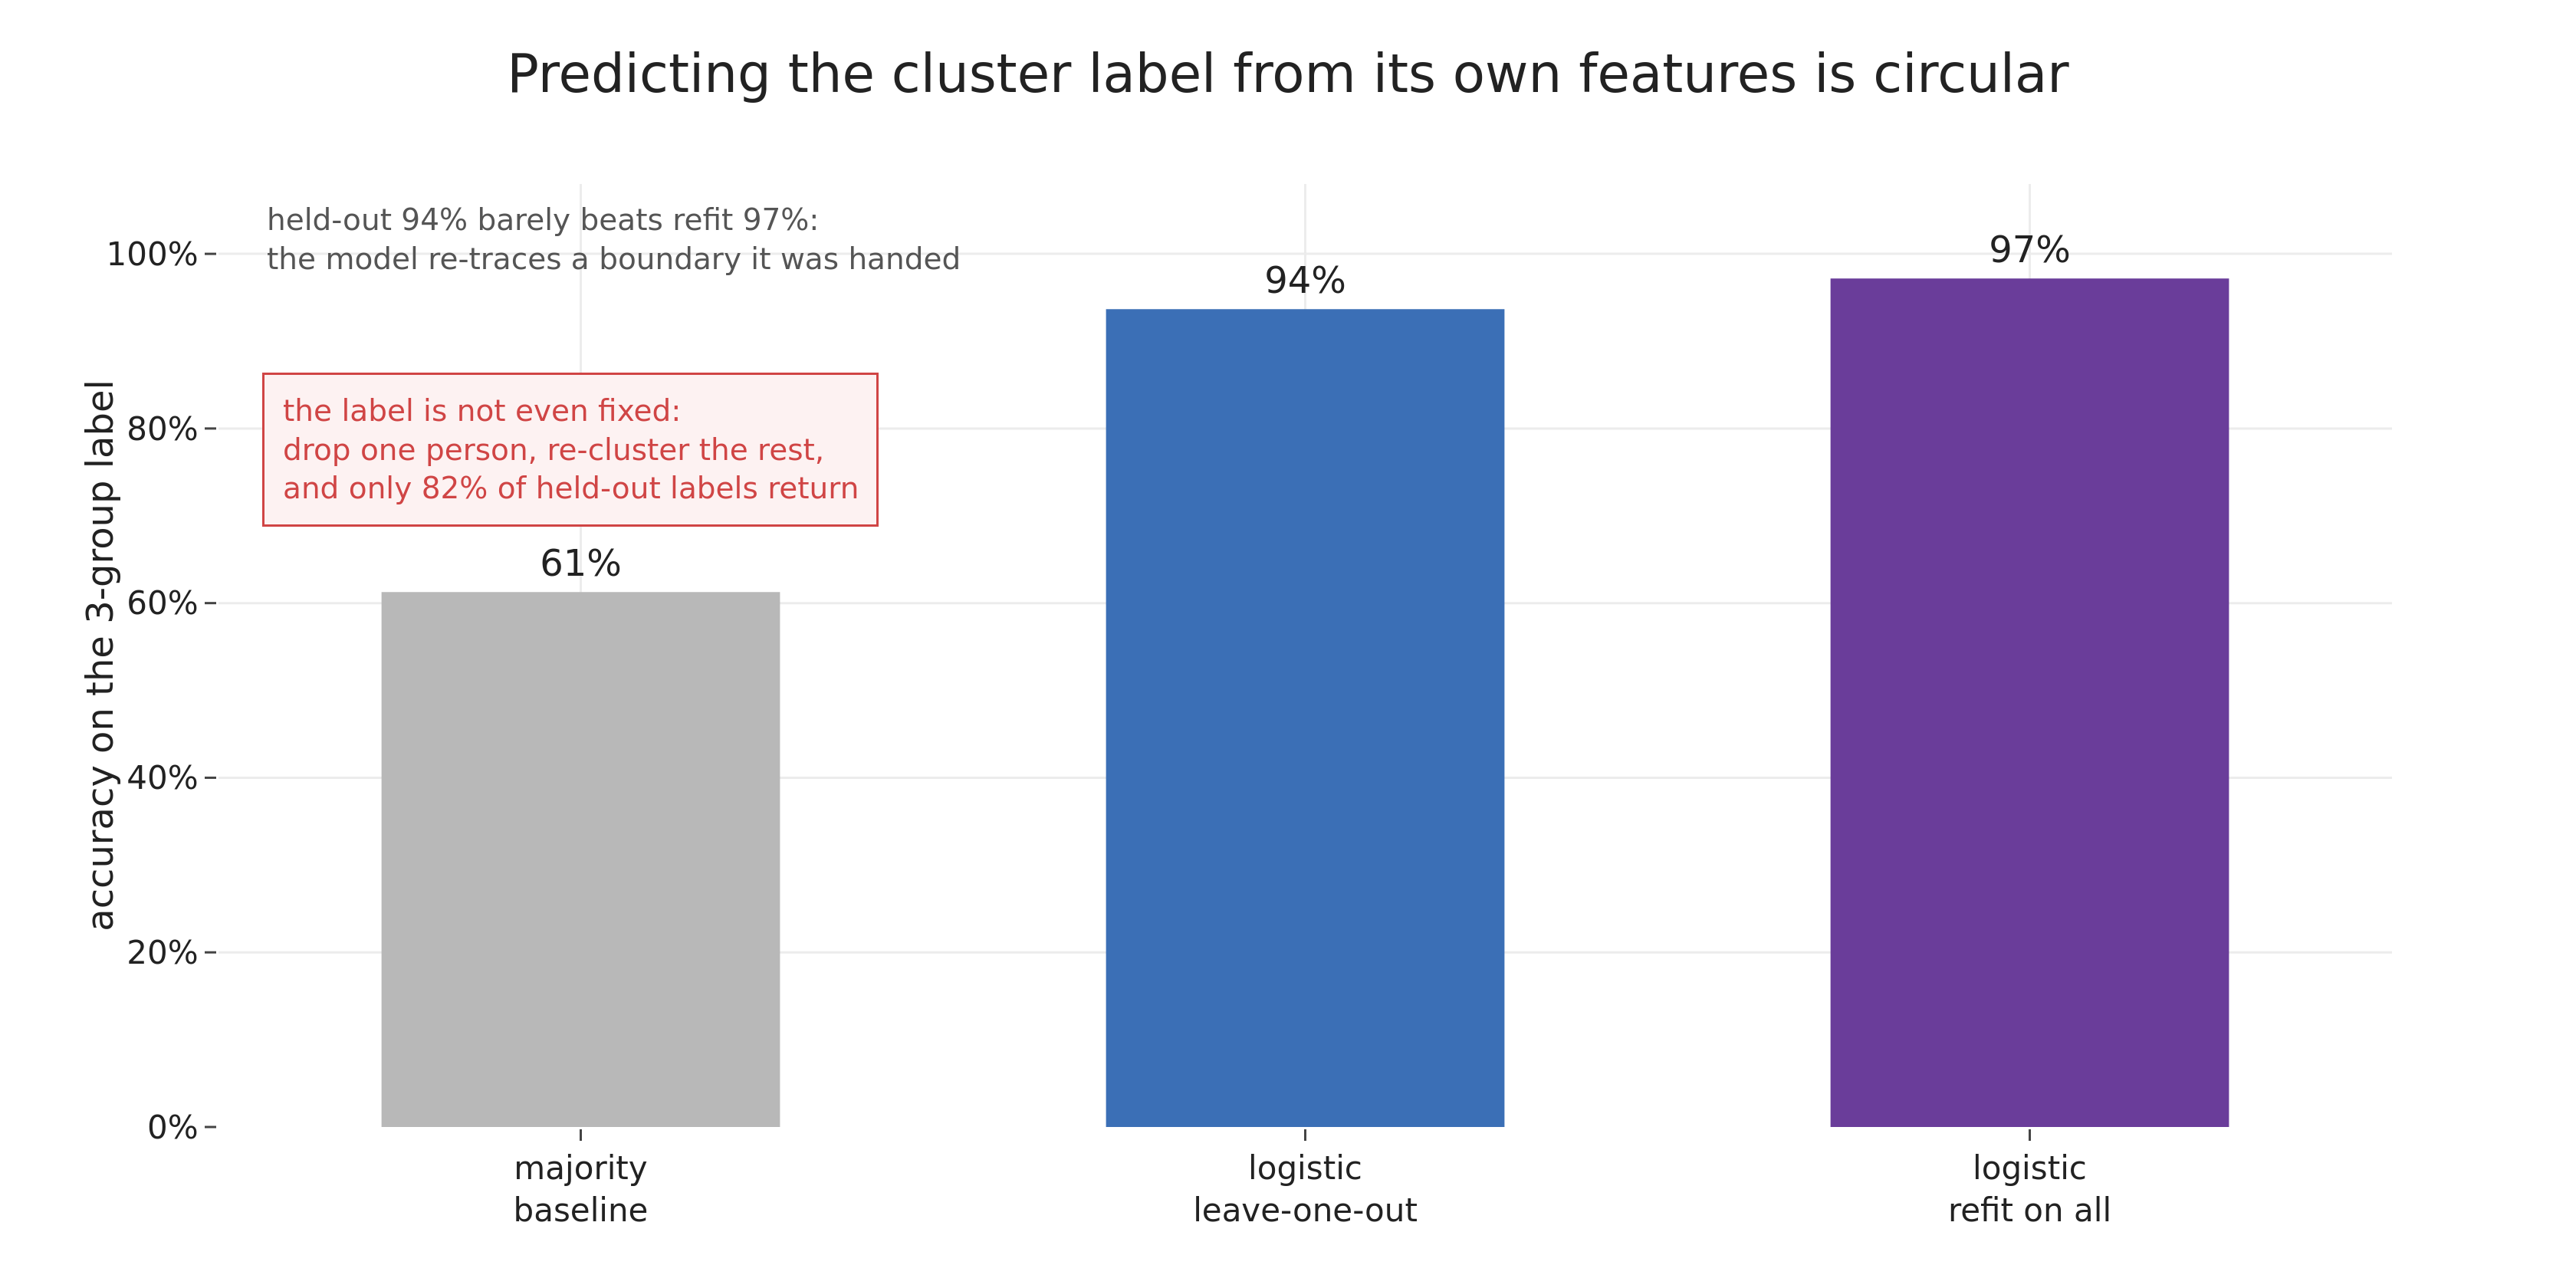

In [3]:
base = float(pd.Series(clabel).value_counts(normalize=True).max())
clf_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
loo_acc = float((cross_val_predict(clf_c, X, clabel, cv=LeaveOneOut()) == clabel).mean())
resub = float(clf_c.fit(X, clabel).score(X, clabel))

def reclustered_label(i):
    # drop person i, re-cluster the rest, map clusters back by overlap, assign i by nearest centroid
    m = np.ones(len(keep), bool); m[i] = False
    sc = StandardScaler().fit(X[m]); Xi = sc.transform(X[m])
    li = fcluster(linkage(Xi, "ward"), 3, "maxclust")
    cents = np.array([Xi[li == k].mean(0) for k in (1, 2, 3)])
    xi = sc.transform(X[i:i + 1])[0]
    near = (1, 2, 3)[int(np.argmin(np.linalg.norm(cents - xi, axis=1)))]
    full = np.full(len(keep), -1); full[m] = li
    M = np.array([[np.sum((clabel == p) & (full == q)) for q in (1, 2, 3)] for p in (1, 2, 3)])
    r, c = linear_sum_assignment(-M); mp = {c[j] + 1: r[j] + 1 for j in range(3)}
    return mp[near]
stable = float(np.mean([reclustered_label(i) == clabel[i] for i in range(len(keep))]))
print(f"baseline {base:.3f}  LOO {loo_acc:.3f}  resubstitution {resub:.3f}  label-stability {stable:.3f}")

rows = ["majority<br>baseline", "logistic<br>leave-one-out", "logistic<br>refit on all"]
vals = [base, loo_acc, resub]
fig = go.Figure(go.Bar(x=rows, y=[v * 100 for v in vals], marker_color=[GREY, BLUE, PURPLE], width=0.55,
    text=[f"{v:.0%}" for v in vals], textposition="outside", textfont=dict(size=16), cliponaxis=False))
fig.add_annotation(xref="paper", yref="paper", x=0.02, y=0.985, showarrow=False, xanchor="left", align="left",
    text="held-out 94% barely beats refit 97%:<br>the model re-traces a boundary it was handed",
    font=dict(size=13, color="#555"))
fig.add_annotation(xref="paper", yref="paper", x=0.02, y=0.80, showarrow=False, xanchor="left", align="left",
    text=f"the label is not even fixed:<br>drop one person, re-cluster the rest,<br>"
         f"and only {stable:.0%} of held-out labels return",
    font=dict(size=13, color=RED), bordercolor=RED, borderwidth=1, borderpad=8, bgcolor="#fdf2f2")
fig.update_yaxes(title_text="accuracy on the 3-group label", range=[0, 108], ticksuffix="%")
fig.update_layout(title="Predicting the cluster label from its own features is circular")
save_fig(fig, "pp1_circularity.png", w=1120, h=560, margin=dict(l=95, r=80, t=80, b=70))

## A target the features never saw

The job-title layer was annotated from an external source and joined after the
fact, so it owes nothing to the email features. Predicting whether a person is
an executive is a genuine test. Executives are rare here (40 of 142), so plain
accuracy would flatter a model that always guessed "no"; the ROC curve and a
balanced-accuracy figure judge it fairly, and a permutation null over a thousand
label shuffles says whether the result could have come up by chance.

AUC 0.800  balanced acc 0.748  null mean 0.495  p 0.0010


/tmp/ipykernel_469622/3317187253.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


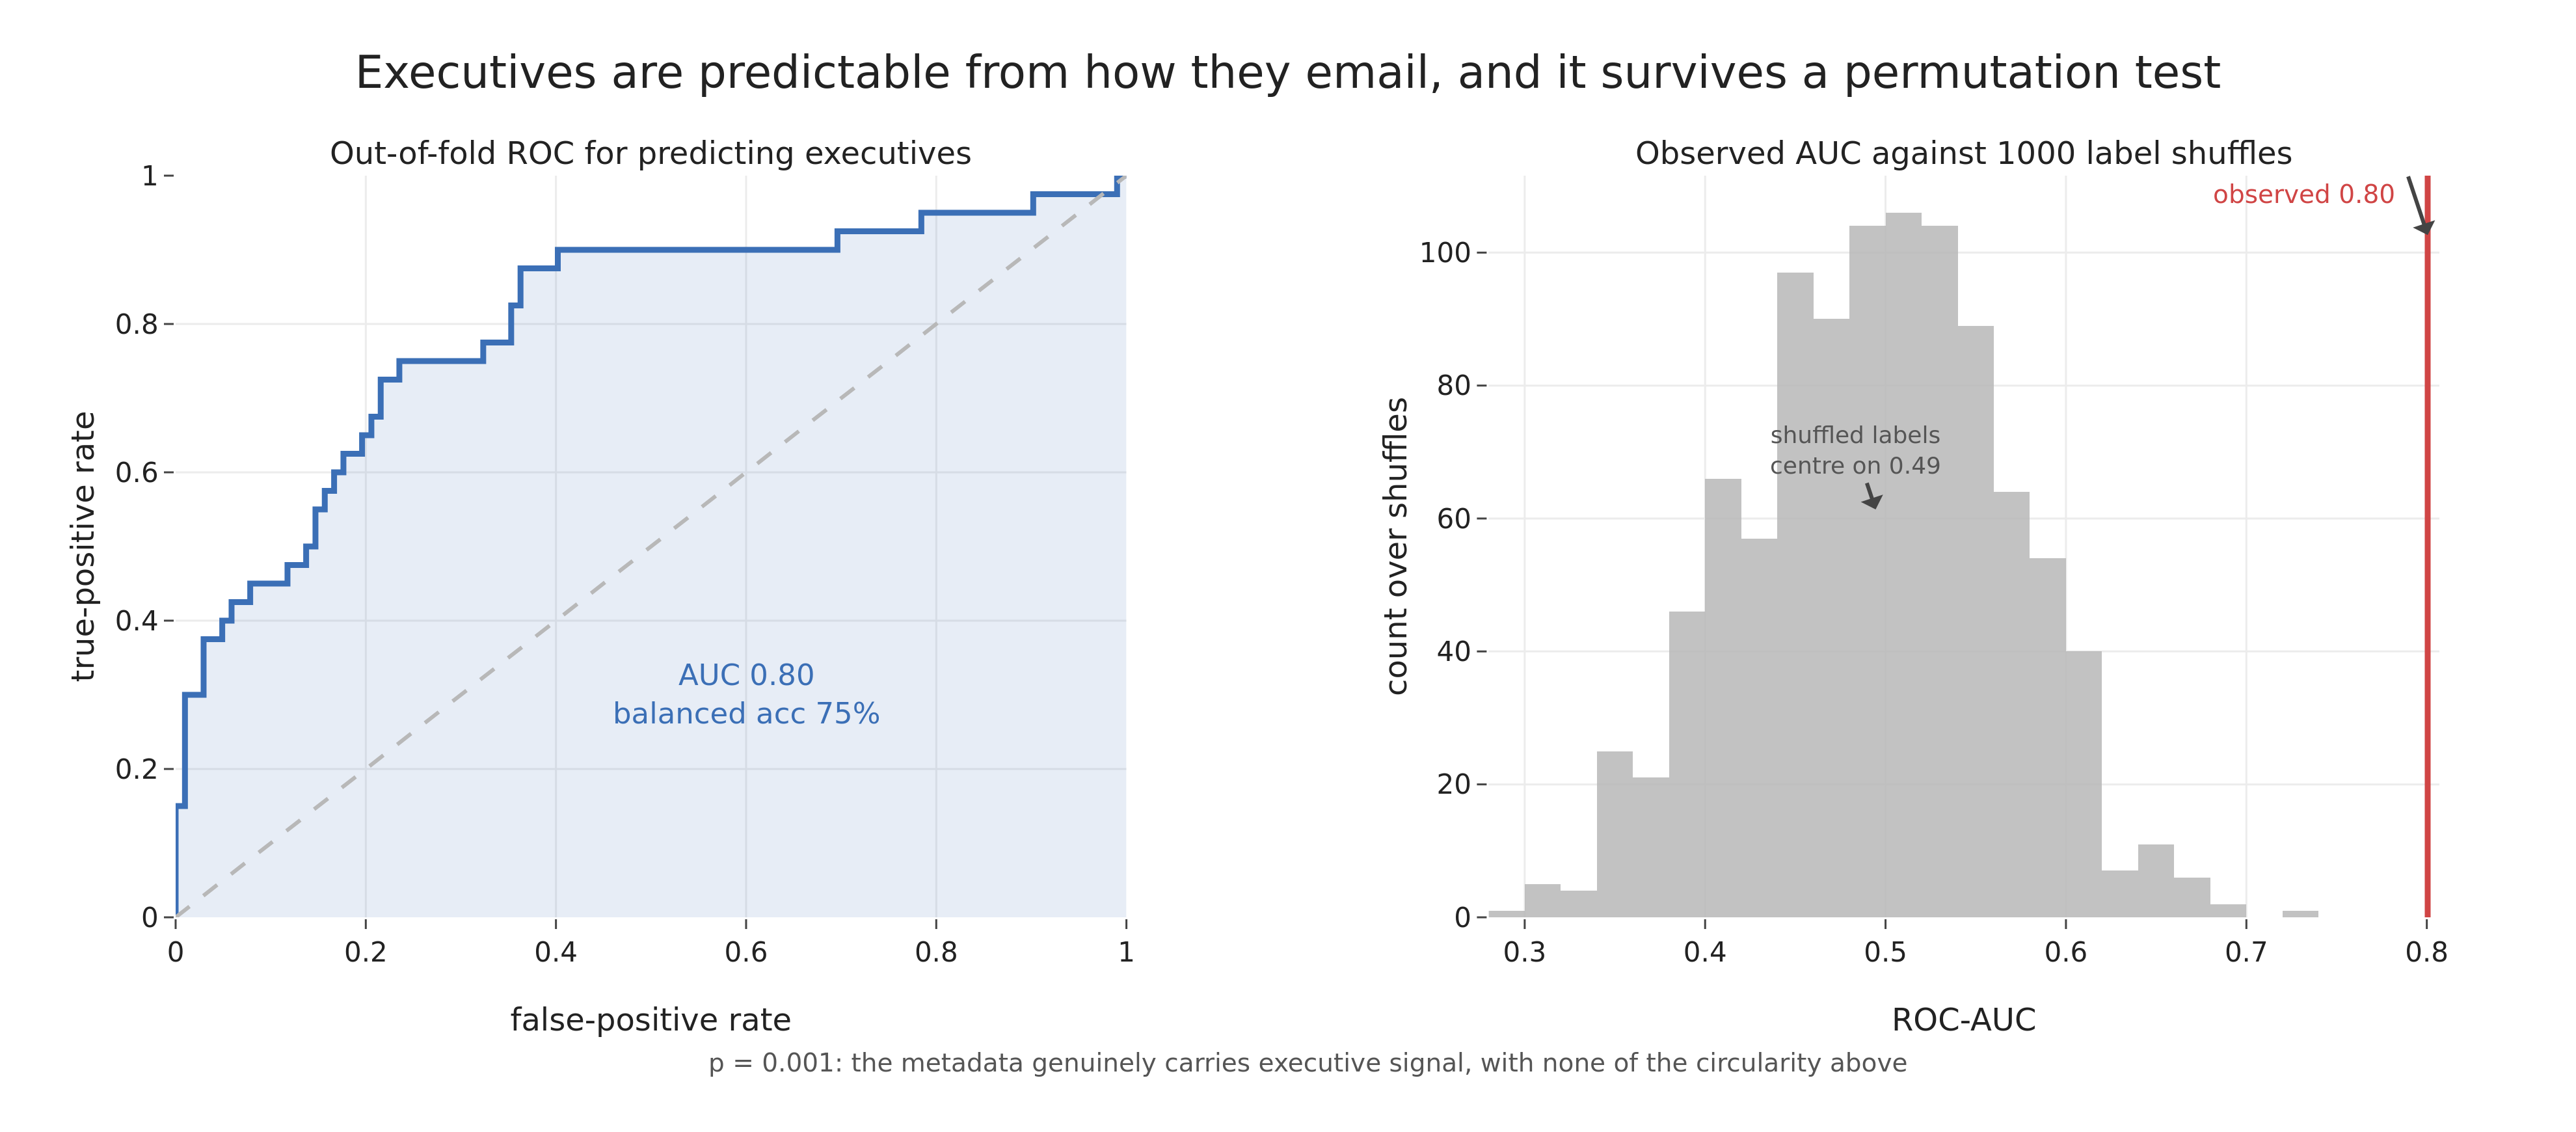

In [4]:
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
cv = StratifiedKFold(10, shuffle=True, random_state=0)
proba = cross_val_predict(clf, X, y_exec, cv=cv, method="predict_proba")[:, 1]
auc = roc_auc_score(y_exec, proba)
bacc = balanced_accuracy_score(y_exec, (proba >= 0.5).astype(int))
fpr, tpr, _ = roc_curve(y_exec, proba)

rng = np.random.default_rng(0)
NPERM = 1000
null = np.empty(NPERM)
for i in range(NPERM):
    yp = rng.permutation(y_exec)
    null[i] = roc_auc_score(yp, cross_val_predict(clf, X, yp, cv=cv, method="predict_proba")[:, 1])
p_exec = (int(np.sum(null >= auc)) + 1) / (NPERM + 1)
print(f"AUC {auc:.3f}  balanced acc {bacc:.3f}  null mean {null.mean():.3f}  p {p_exec:.4f}")

fig = make_subplots(rows=1, cols=2, column_widths=[0.5, 0.5], horizontal_spacing=0.16,
    subplot_titles=["Out-of-fold ROC for predicting executives",
                    "Observed AUC against 1000 label shuffles"])
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", line=dict(color=BLUE, width=3),
    fill="tozeroy", fillcolor="rgba(59,111,182,0.12)", showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(color=GREY, dash="dash", width=2),
    showlegend=False), row=1, col=1)
fig.add_annotation(x=0.6, y=0.30, text=f"AUC {auc:.2f}<br>balanced acc {bacc:.0%}", showarrow=False,
    font=dict(size=15, color=BLUE), row=1, col=1)
fig.update_xaxes(title_text="false-positive rate", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="true-positive rate", range=[0, 1], row=1, col=1)

fig.add_trace(go.Histogram(x=null, nbinsx=42, marker_color=GREY, opacity=0.85, showlegend=False), row=1, col=2)
fig.add_vline(x=auc, line=dict(color=RED, width=3), row=1, col=2)
fig.add_annotation(xref="x2", yref="y2 domain", x=auc, y=0.92, yanchor="top", xanchor="right",
    text=f"observed {auc:.2f} ", font=dict(size=13, color=RED))
fig.add_annotation(xref="x2", yref="y2 domain", x=float(null.mean()), y=0.55, xanchor="center",
    text=f"shuffled labels<br>centre on {null.mean():.2f}", font=dict(size=12, color="#555"))
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=-0.22, showarrow=False, xanchor="center",
    text=f"p = {p_exec:.3f}: the metadata genuinely carries executive signal, with none of the circularity above",
    font=dict(size=13, color="#555"))
fig.update_xaxes(title_text="ROC-AUC", row=1, col=2)
fig.update_yaxes(title_text="count over shuffles", row=1, col=2)
fig.update_layout(title="Executives are predictable from how they email, and it survives a permutation test")
save_fig(fig, "pp2_executive_prediction.png", w=1320, h=580, margin=dict(l=90, r=70, t=90, b=110))

## Where the signal sits, and how the targets compare

The same twelve features predict seniority rank with a cross-validated Spearman
correlation, predict executive status at AUC 0.80, predict the circular cluster
label at 0.94, and recover almost nothing from the message body (the week-5
result). Scaling each to its own chance-to-perfect range puts them on one axis.
The standardised logistic weights on the right show the behaviour behind the
executive signal: many distinct people writing in, more recipients per message,
and little mass-broadcasting.

seniority Spearman 0.468  null mean -0.140  p 0.0010


/tmp/ipykernel_469622/3317187253.py:47: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


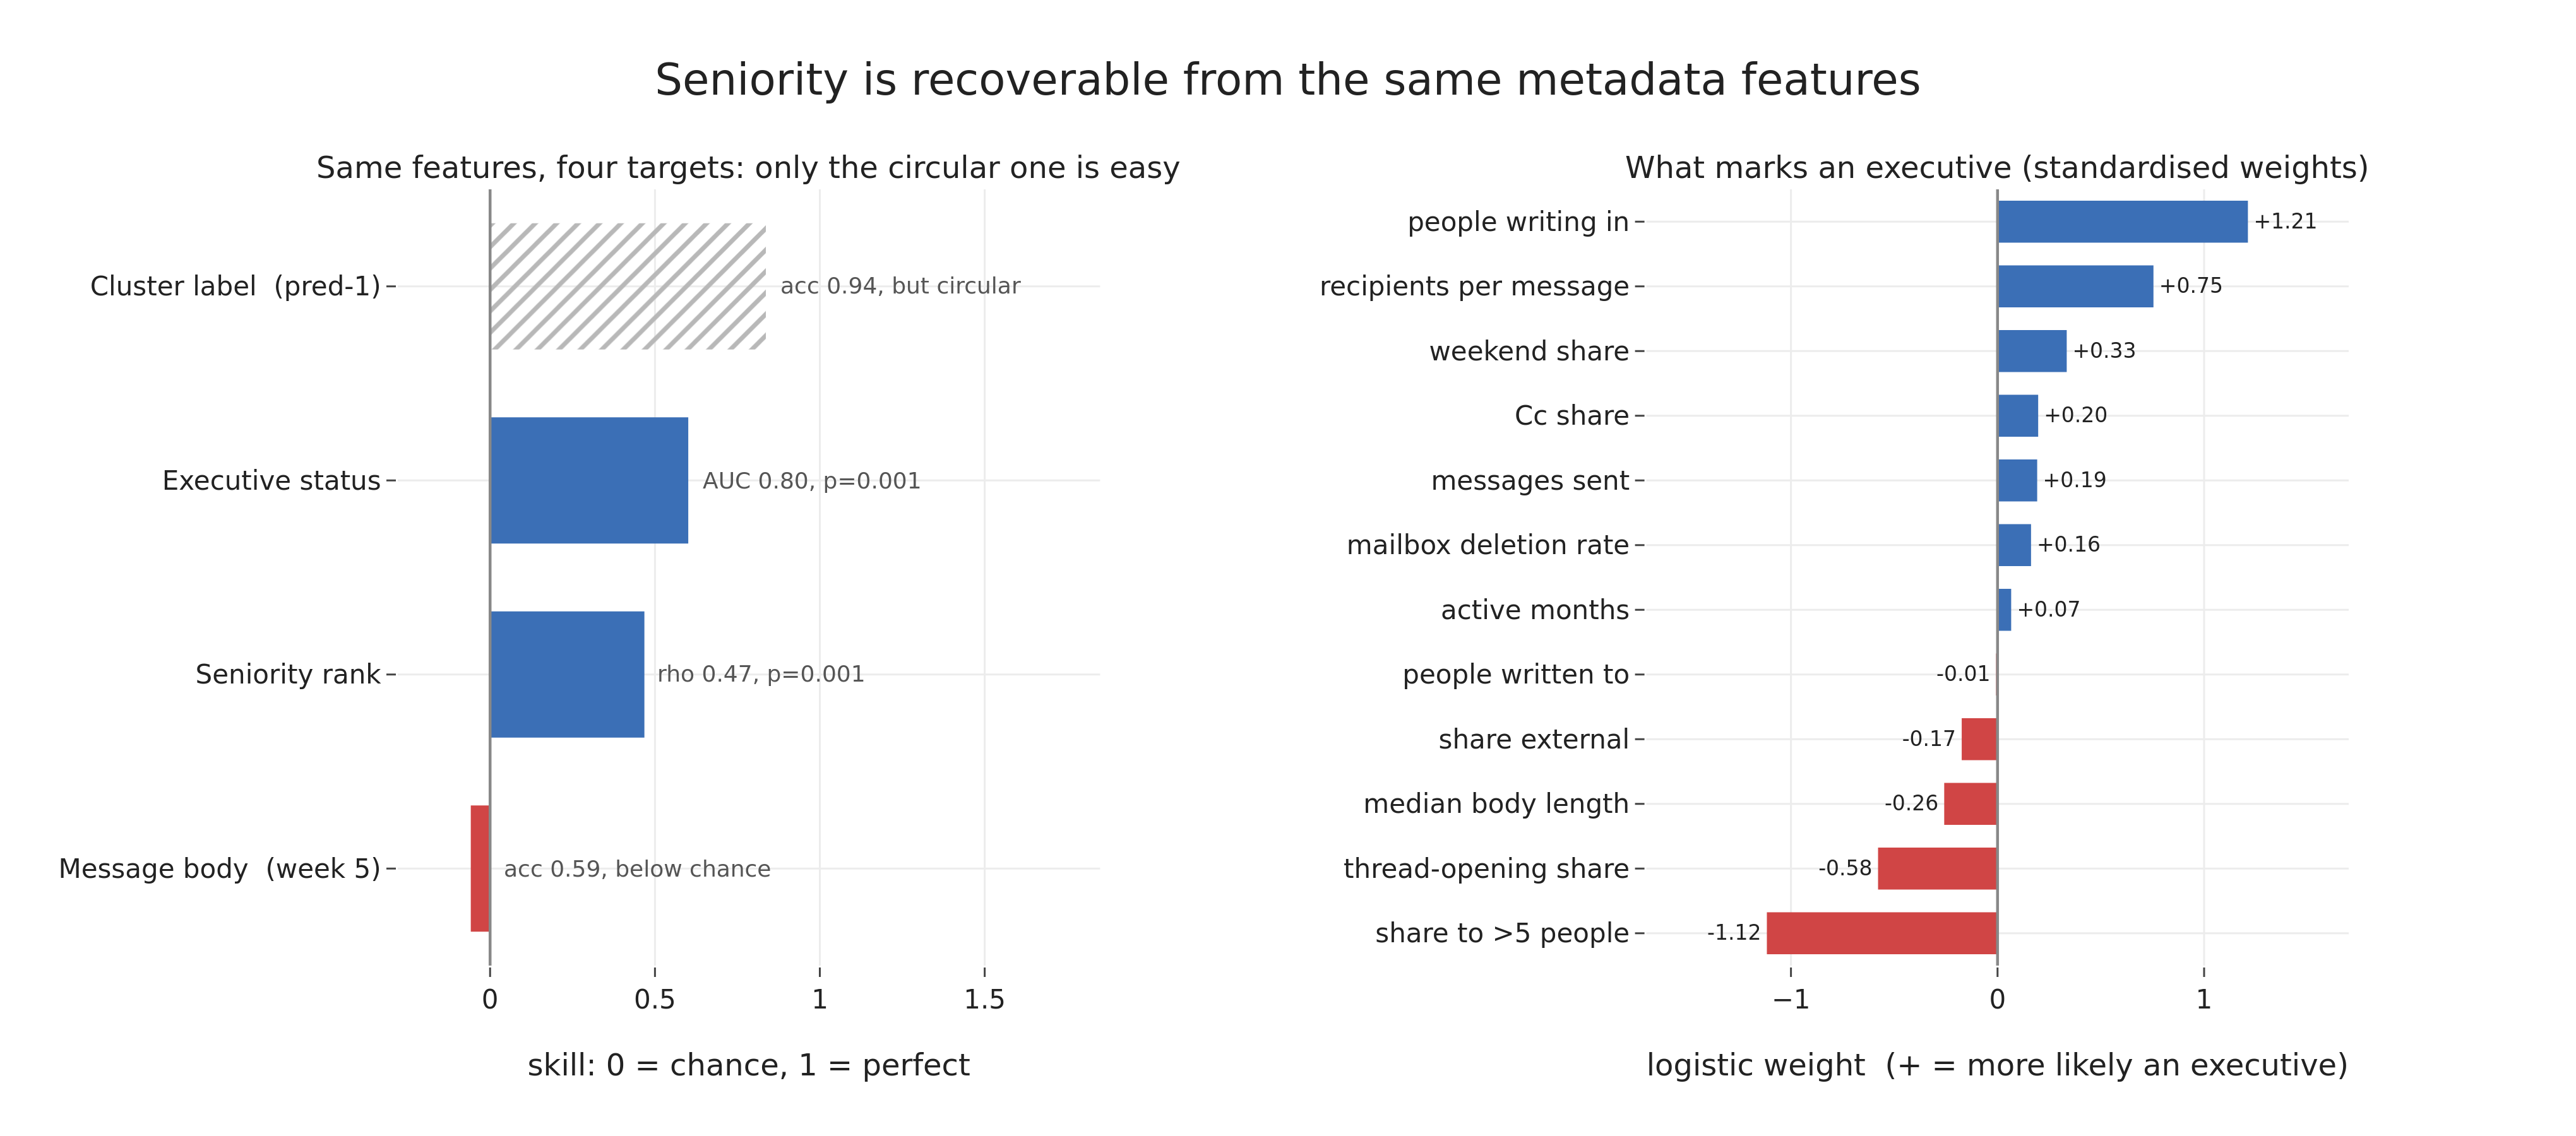

In [5]:
reg = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
cvr = KFold(10, shuffle=True, random_state=0)
pred_rank = cross_val_predict(reg, X, y_rank, cv=cvr)
rho = float(spearmanr(y_rank, pred_rank).statistic)
rng2 = np.random.default_rng(1)
nullr = np.array([spearmanr(yp := rng2.permutation(y_rank),
                            cross_val_predict(reg, X, yp, cv=cvr)).statistic for _ in range(1000)])
p_rank = (int(np.sum(nullr >= rho)) + 1) / 1001
print(f"seniority Spearman {rho:.3f}  null mean {nullr.mean():.3f}  p {p_rank:.4f}")

skill = [
    ("Cluster label  (pred-1)", (loo_acc - base) / (1 - base), "acc 0.94, but circular", GREY, "/"),
    ("Executive status",        2 * auc - 1,                    f"AUC {auc:.2f}, p={p_exec:.3f}", BLUE, ""),
    ("Seniority rank",          rho,                            f"rho {rho:.2f}, p={p_rank:.3f}", BLUE, ""),
    ("Message body  (week 5)",  (0.59 - base) / (1 - base),     "acc 0.59, below chance", RED, ""),
]
names = [s[0] for s in skill][::-1]; sv = [s[1] for s in skill][::-1]
txt = [s[2] for s in skill][::-1]; bc = [s[3] for s in skill][::-1]; patt = [s[4] for s in skill][::-1]

lr = LogisticRegression(max_iter=5000, class_weight="balanced").fit(Xs, y_exec)
coef = pd.Series(lr.coef_[0], index=FEATS).sort_values()
cf_names = [PRETTY[f] for f in coef.index]
cf_cols = [RED if v < 0 else BLUE for v in coef.values]

fig = make_subplots(rows=1, cols=2, column_widths=[0.5, 0.5], horizontal_spacing=0.28,
    subplot_titles=["Same features, four targets: only the circular one is easy",
                    "What marks an executive (standardised weights)"])
fig.add_trace(go.Bar(y=names, x=sv, orientation="h", marker=dict(color=bc, pattern=dict(shape=patt)),
    cliponaxis=False, showlegend=False), row=1, col=1)
fig.add_vline(x=0, line=dict(color="#888", width=1.5), row=1, col=1)
for nm, v, t in zip(names, sv, txt):
    fig.add_annotation(x=max(v, 0.0) + 0.03, y=nm, text=t, showarrow=False, xanchor="left",
        font=dict(size=12, color="#555"), row=1, col=1)
fig.update_xaxes(title_text="skill: 0 = chance, 1 = perfect", range=[-0.28, 1.85], row=1, col=1)

fig.add_trace(go.Bar(y=cf_names, x=coef.values, orientation="h", marker_color=cf_cols,
    text=[f"{v:+.2f}" for v in coef.values], textposition="outside", textfont=dict(size=11),
    cliponaxis=False, showlegend=False), row=1, col=2)
fig.add_vline(x=0, line=dict(color="#888", width=1.5), row=1, col=2)
fig.update_xaxes(title_text="logistic weight  (+ = more likely an executive)", range=[-1.7, 1.7], row=1, col=2)
fig.update_layout(title="Seniority is recoverable from the same metadata features",
    bargap=0.35)
save_fig(fig, "pp3_targets_and_drivers.png", w=1360, h=600, margin=dict(l=210, r=120, t=100, b=90))

## What pred-2 adds

The 94% from pred-1 measures how cleanly the clustering split its own feature
space, a geometric fact about the partition. Against a real external target the
same features still carry weight: executive status comes out at AUC 0.80 and
seniority rank at a Spearman of about 0.47, both far above their permutation
nulls. The giveaway is in-degree: an executive is written to by many distinct
people, which is why this signal hid inside the broadcast-driven three-way split
and only shows up when the question is asked directly.